# Introduction

In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [24]:
raw_data="https://gist.githubusercontent.com/anu-006/09ca1e8ecb9f5bda27f68b829cc41a5d/raw/4333c53f17ff365f05404a1398707494140a8c08/smartphone_battery_drain_dataset"

In [25]:
data=pd.read_csv(raw_data)
data

,App_Running,Screen_On_Time_min,CPU_Usage_%,Battery_Temperature_C,Battery_Drop_Per_Hour,Network_Type,Brightness_Level_%,RAM_Usage_MB,Charging_State,Usage_Mode
0,Facebook,70.779244,55.550655,34.301005,6.020228,5G,57,2941.852469,Charging,Gaming
1,PUBG,90.044282,10.506832,35.607895,13.372379,WiFi,10,1930.581458,Not Charging,Social Media
2,Maps,75.197224,38.529769,43.312775,3.514550,5G,37,2169.828899,Charging,Social Media
3,WhatsApp,114.762495,26.898454,33.795197,6.728475,WiFi,33,2329.369145,Charging,Browsing
4,Facebook,52.214675,36.862349,41.089636,19.134837,5G,25,2175.002939,Charging,Video Streaming
...,...,...,...,...,...,...,...,...,...,...
2498,Instagram,56.488493,24.271686,40.431544,13.258253,WiFi,63,2187.176944,Not Charging,Gaming
2499,WhatsApp,80.865618,33.550557,24.552252,17.555962,5G,17,2653.751518,Charging,Gaming
2500,Chrome,64.043076,48.248489,26.177555,12.686444,WiFi,97,2734.017392,Not Charging,Browsing
2501,PUBG,85.989414,51.872556,29.039868,10.659386,4G,69,2451.633483,Charging,Browsing


In [26]:
data.shape

(2503, 10)

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2503 entries, 0 to 2502
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   App_Running            2503 non-null   object 
 1   Screen_On_Time_min     2503 non-null   float64
 2   CPU_Usage_%            2498 non-null   float64
 3   Battery_Temperature_C  2498 non-null   float64
 4   Battery_Drop_Per_Hour  2503 non-null   float64
 5   Network_Type           2503 non-null   object 
 6   Brightness_Level_%     2503 non-null   int64  
 7   RAM_Usage_MB           2503 non-null   float64
 8   Charging_State         2503 non-null   object 
 9   Usage_Mode             2503 non-null   object 
dtypes: float64(5), int64(1), object(4)
memory usage: 195.7+ KB


# Missing Value Analysis

In [28]:
(data.isnull().sum()/len(data))*100

,0
App_Running,0.00000
Screen_On_Time_min,0.00000
CPU_Usage_%,0.19976
Battery_Temperature_C,0.19976
Battery_Drop_Per_Hour,0.00000
Network_Type,0.00000
Brightness_Level_%,0.00000
RAM_Usage_MB,0.00000
Charging_State,0.00000
Usage_Mode,0.00000


# Data Cleaning

In [29]:
data.dropna(inplace=True)

Removed rows with missing values because the missing proportion is extremely small.


In [30]:
data.describe()

,Screen_On_Time_min,CPU_Usage_%,Battery_Temperature_C,Battery_Drop_Per_Hour,Brightness_Level_%,RAM_Usage_MB
count,2493.000000,2493.000000,2493.000000,2493.000000,2493.000000,2493.000000
mean,79.869212,34.473129,34.988402,11.954727,51.942639,2195.693225
std,24.587575,15.009569,5.140090,4.838177,27.547863,590.077789
min,5.000000,1.000000,20.000000,1.000000,5.000000,500.000000
25%,62.869845,24.222792,31.521404,8.639124,28.000000,1796.987281
50%,79.956587,34.243054,34.969757,11.849794,52.000000,2191.563628
75%,96.914950,44.619185,38.507692,15.136960,76.000000,2593.905280
max,156.548674,83.602087,52.720325,27.516922,99.000000,4145.699243


In [31]:
corr=data.corr(numeric_only=True)
corr

,Screen_On_Time_min,CPU_Usage_%,Battery_Temperature_C,Battery_Drop_Per_Hour,Brightness_Level_%,RAM_Usage_MB
Screen_On_Time_min,1.000000,-0.010047,0.030006,0.039744,0.025774,0.002963
CPU_Usage_%,-0.010047,1.000000,0.037816,-0.014660,-0.005465,0.026310
Battery_Temperature_C,0.030006,0.037816,1.000000,0.024798,-0.002269,-0.005611
Battery_Drop_Per_Hour,0.039744,-0.014660,0.024798,1.000000,-0.027563,-0.023611
Brightness_Level_%,0.025774,-0.005465,-0.002269,-0.027563,1.000000,-0.015845
RAM_Usage_MB,0.002963,0.026310,-0.005611,-0.023611,-0.015845,1.000000


<Axes: >

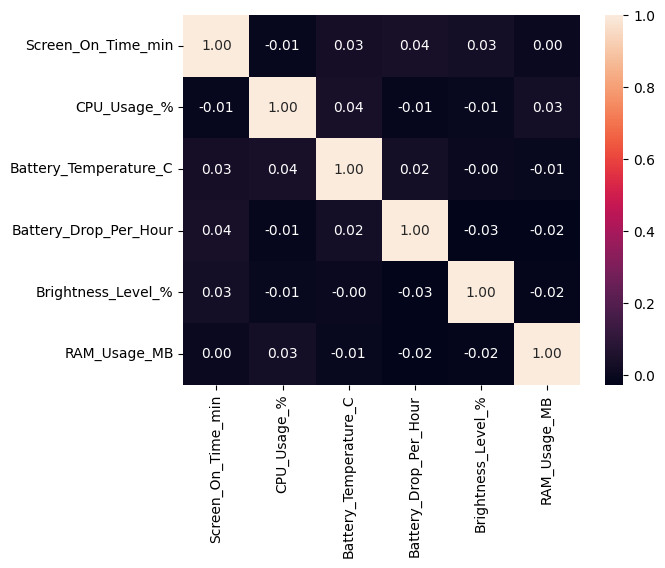

In [32]:
sns.heatmap(corr,annot=True,fmt=".2f")

In [33]:
numerical_cols = data.select_dtypes(include=np.number).columns.tolist()
categorical_cols = data.select_dtypes(include='object').columns.tolist()

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

Numerical columns: ['Screen_On_Time_min', 'CPU_Usage_%', 'Battery_Temperature_C', 'Battery_Drop_Per_Hour', 'Brightness_Level_%', 'RAM_Usage_MB']
Categorical columns: ['App_Running', 'Network_Type', 'Charging_State', 'Usage_Mode']


### Univariate Analysis of Numerical Features

Let's visualize the distribution of each numerical feature using histograms and box plots.

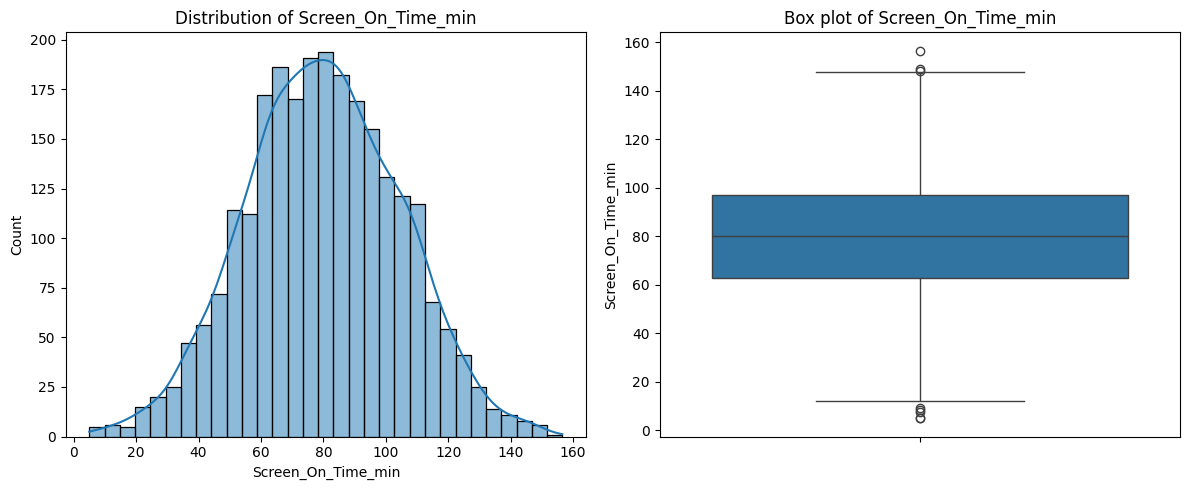

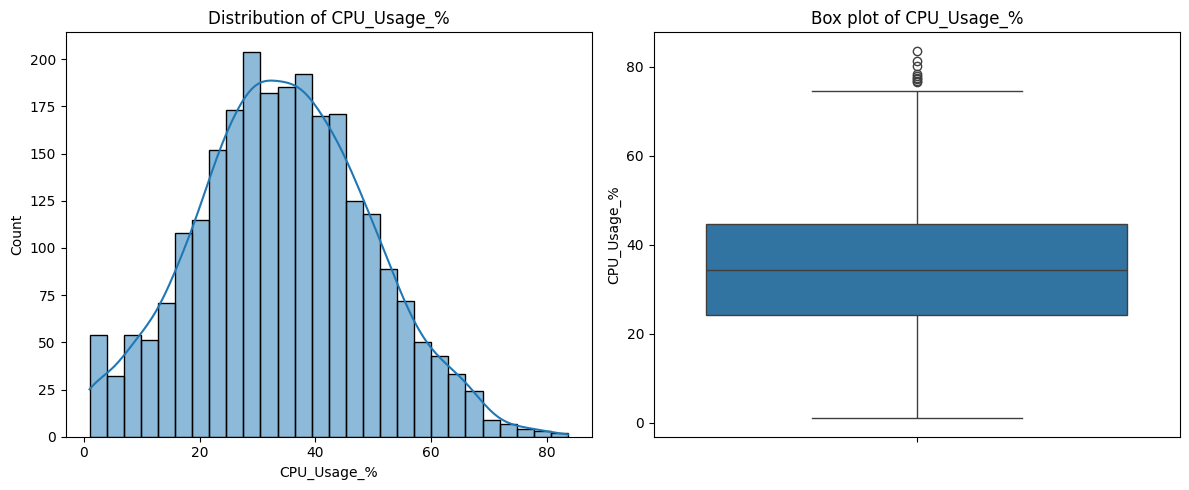

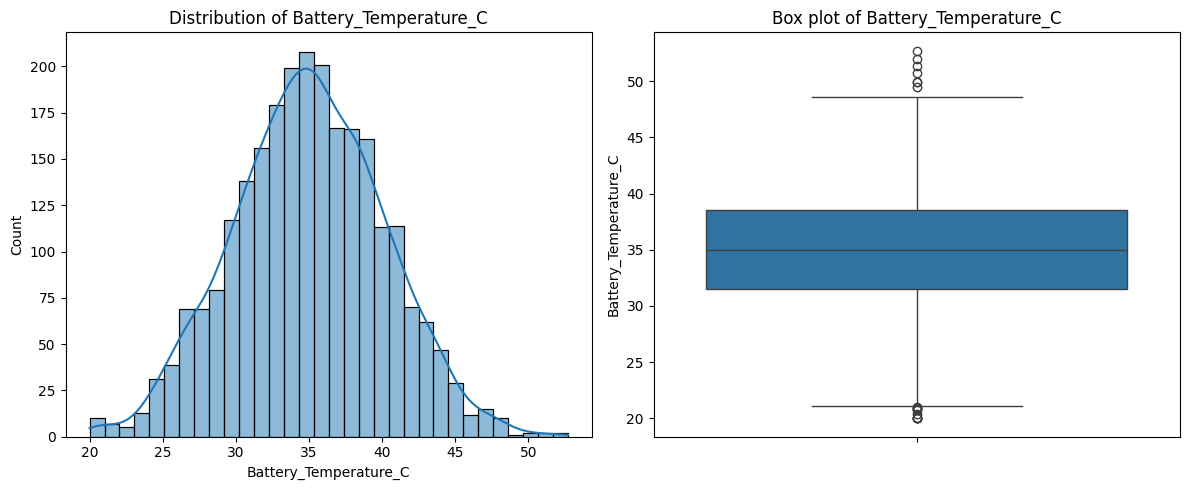

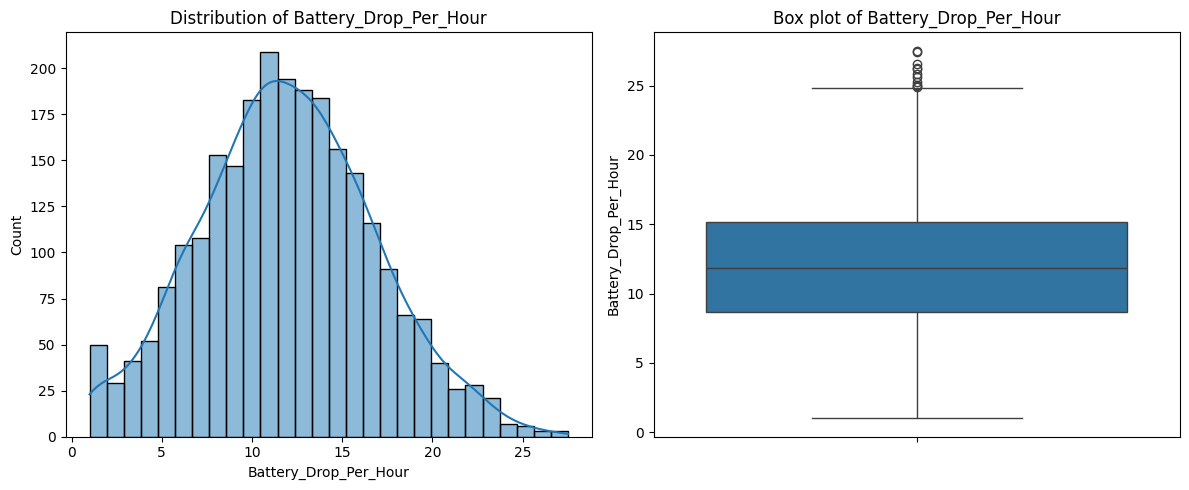

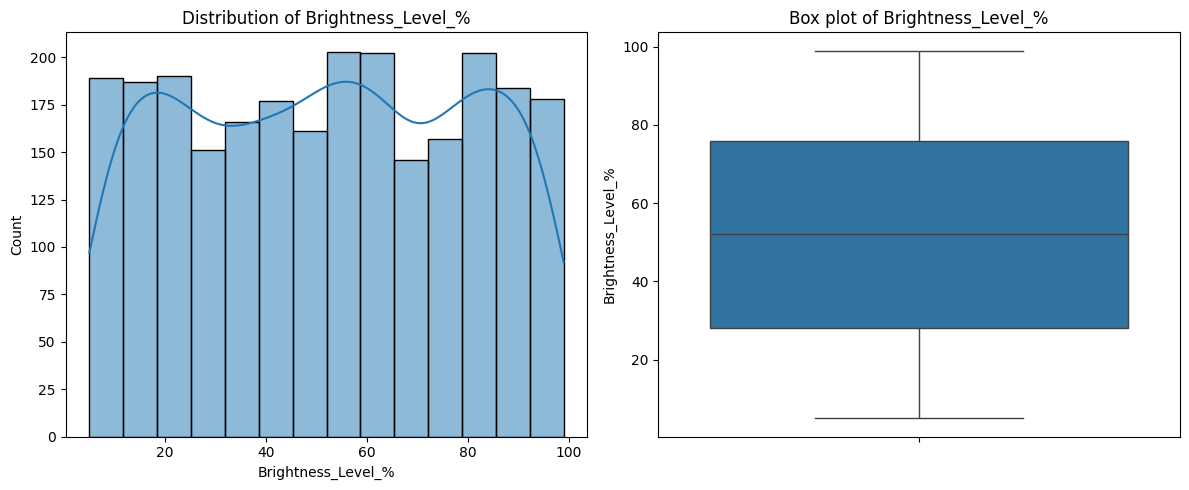

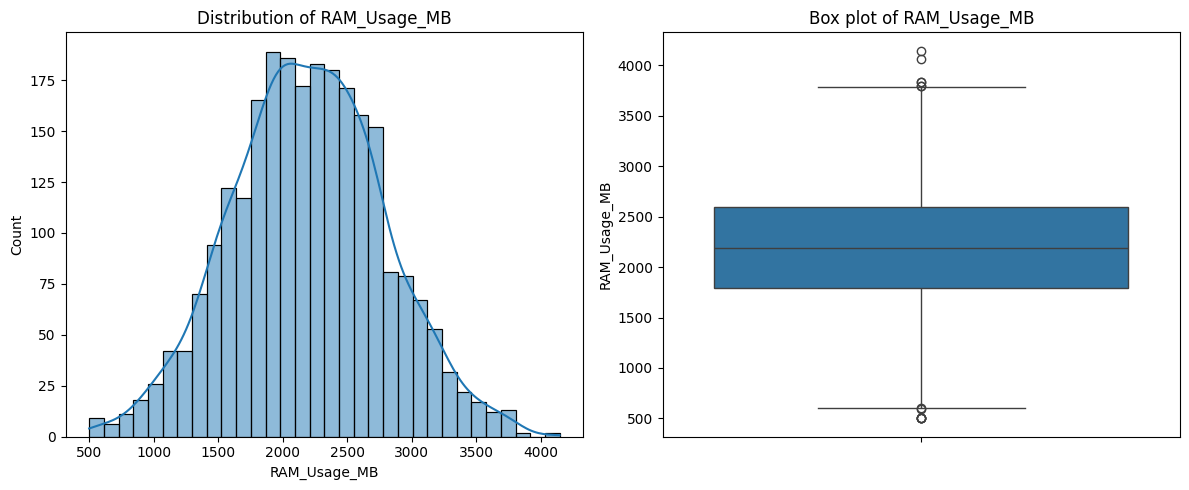

In [34]:
for col in numerical_cols:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')

    plt.subplot(1, 2, 2)
    sns.boxplot(y=data[col])
    plt.title(f'Box plot of {col}')

    plt.tight_layout()
    plt.show()

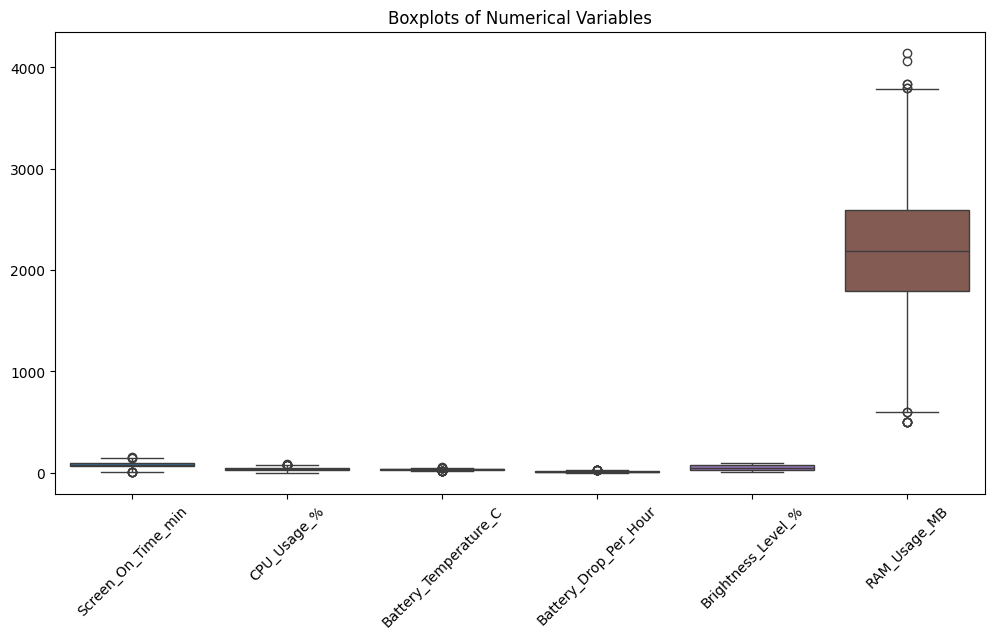

In [35]:
plt.figure(figsize=(12,6))
sns.boxplot(data=data[numerical_cols])
plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Variables")
plt.show()

### Univariate Analysis of Categorical Features

Let's visualize the distribution of each categorical feature using count plots.

/tmp/ipykernel_1124/3648969506.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette='viridis')


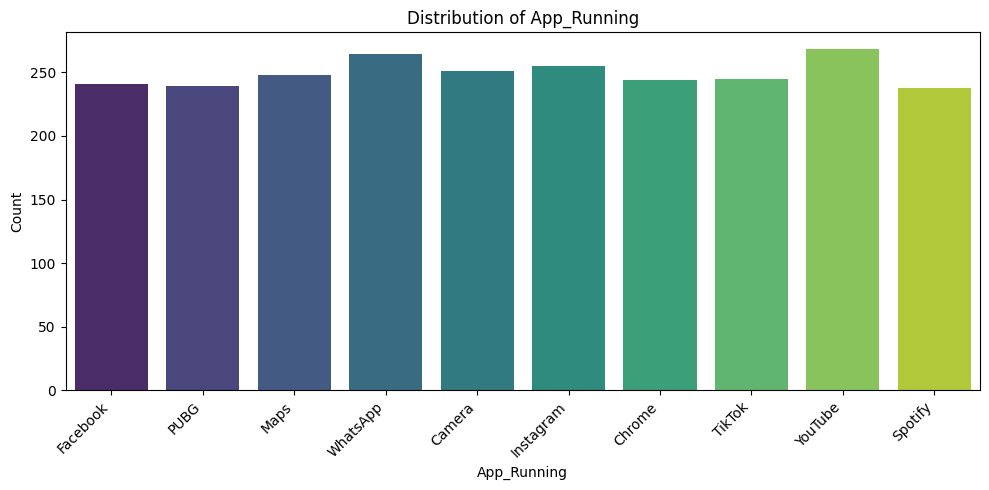

/tmp/ipykernel_1124/3648969506.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette='viridis')


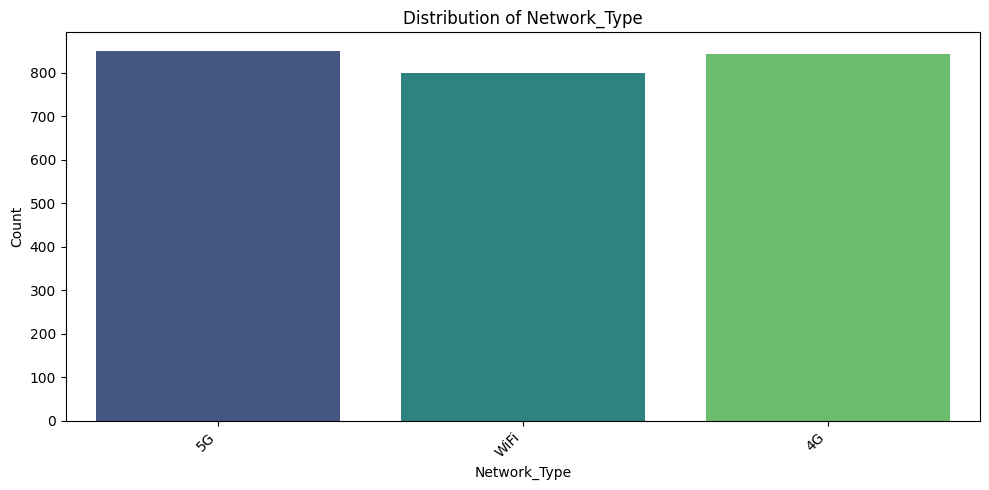

/tmp/ipykernel_1124/3648969506.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette='viridis')


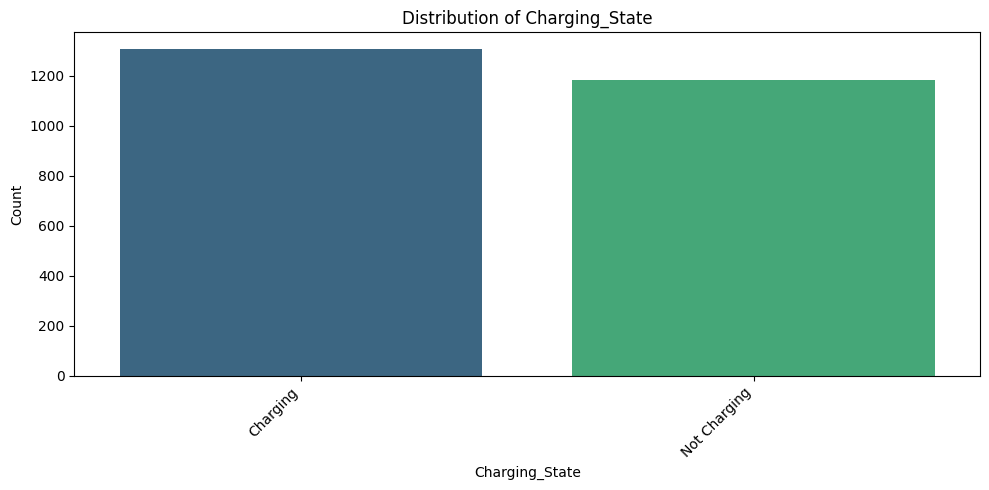

/tmp/ipykernel_1124/3648969506.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette='viridis')


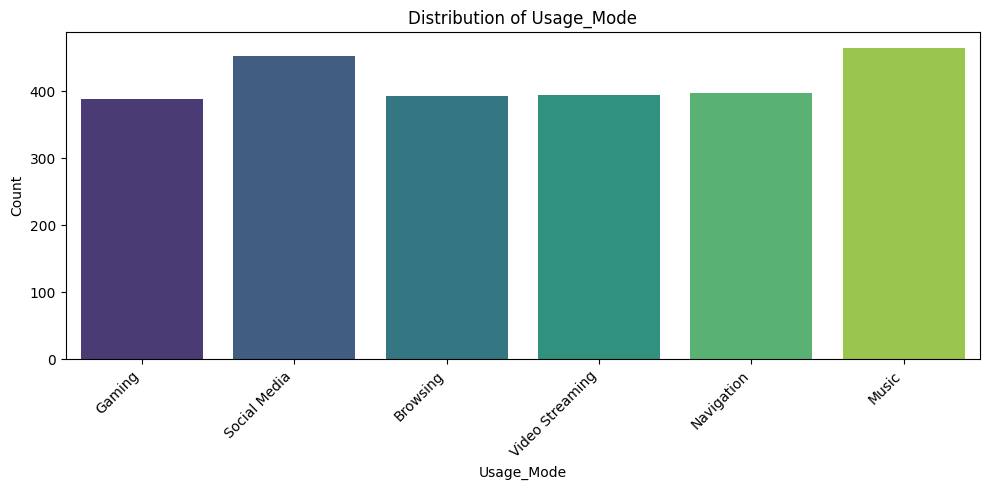

In [36]:
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=data, x=col, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Bivariate Analysis: Numerical Features vs. Battery_Drop_Per_Hour

Let's visualize the relationship between each numerical feature and 'Battery_Drop_Per_Hour' using scatter plots.

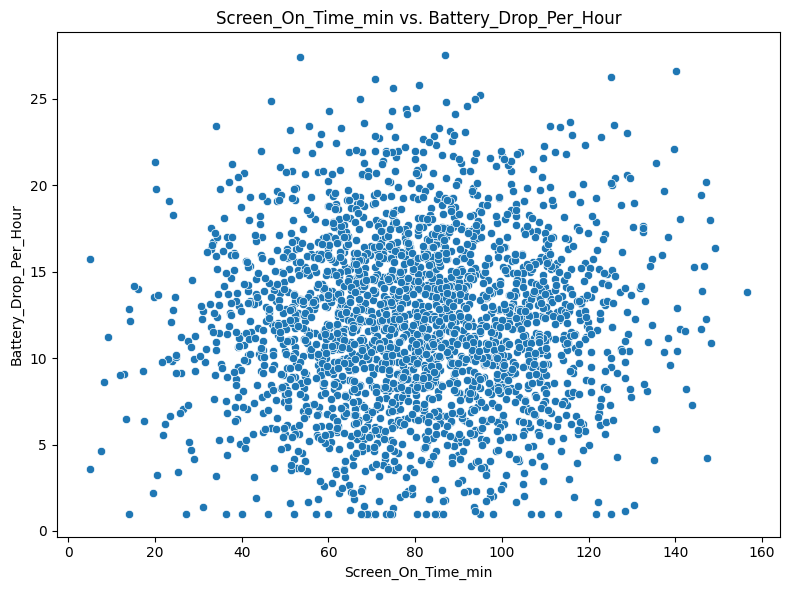

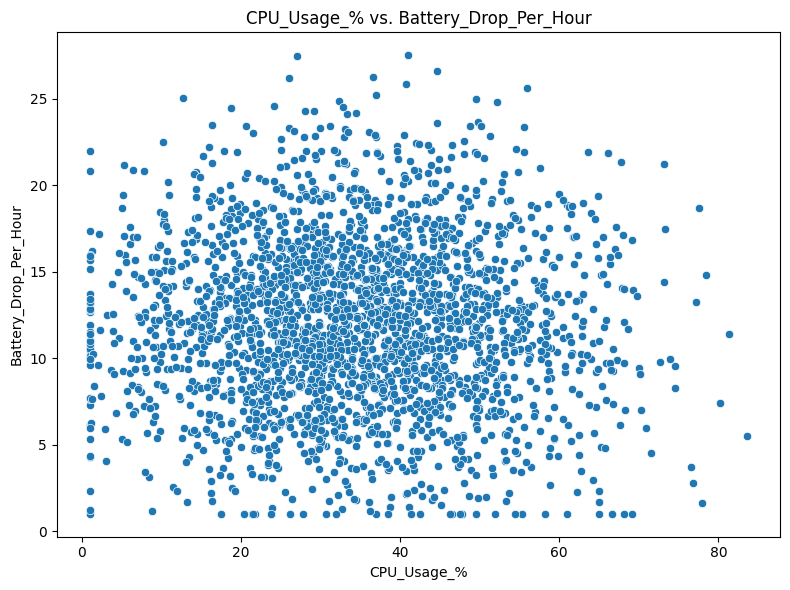

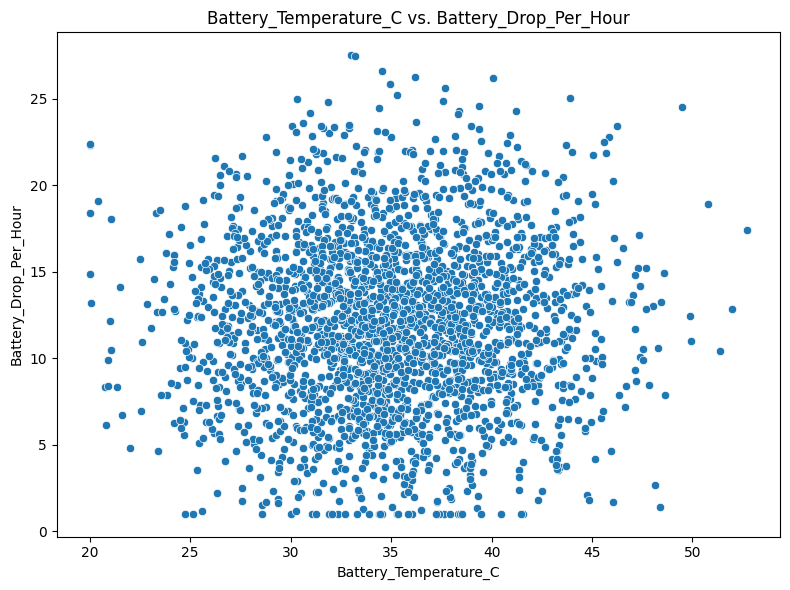

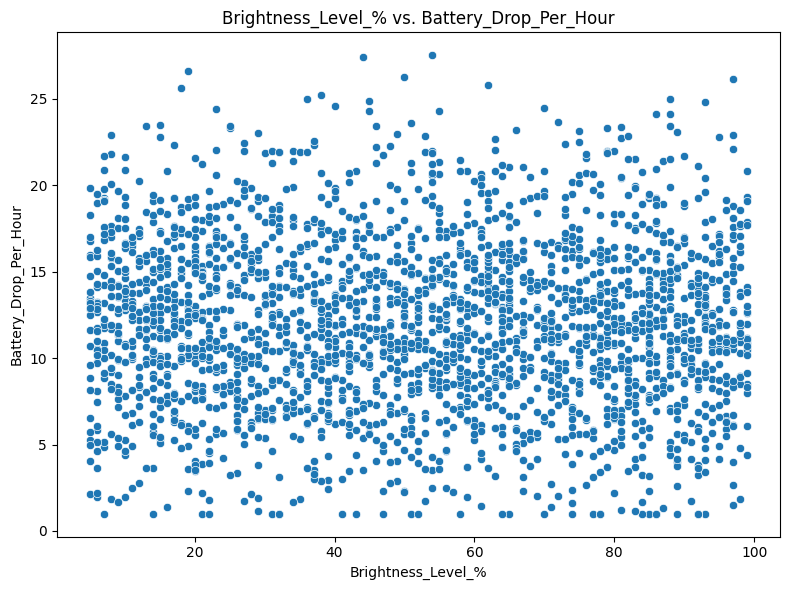

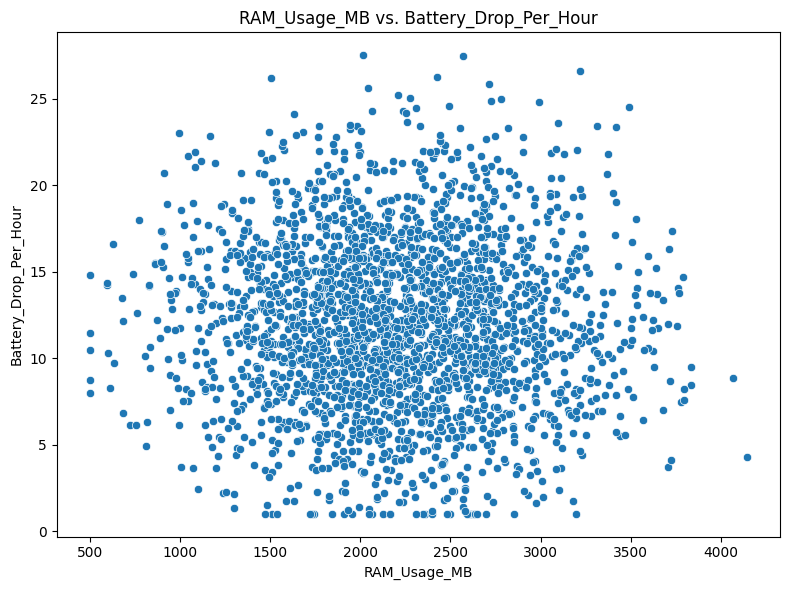

In [37]:
for col in numerical_cols:
    if col != 'Battery_Drop_Per_Hour':
        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=data, x=col, y='Battery_Drop_Per_Hour')
        plt.title(f'{col} vs. Battery_Drop_Per_Hour')
        plt.xlabel(col)
        plt.ylabel('Battery_Drop_Per_Hour')
        plt.tight_layout()
        plt.show()

### Bivariate Analysis: Categorical Features vs. Battery_Drop_Per_Hour

Let's visualize the relationship between each categorical feature and 'Battery_Drop_Per_Hour' using box plots.

/tmp/ipykernel_1124/743069054.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=col, y='Battery_Drop_Per_Hour', palette='viridis')


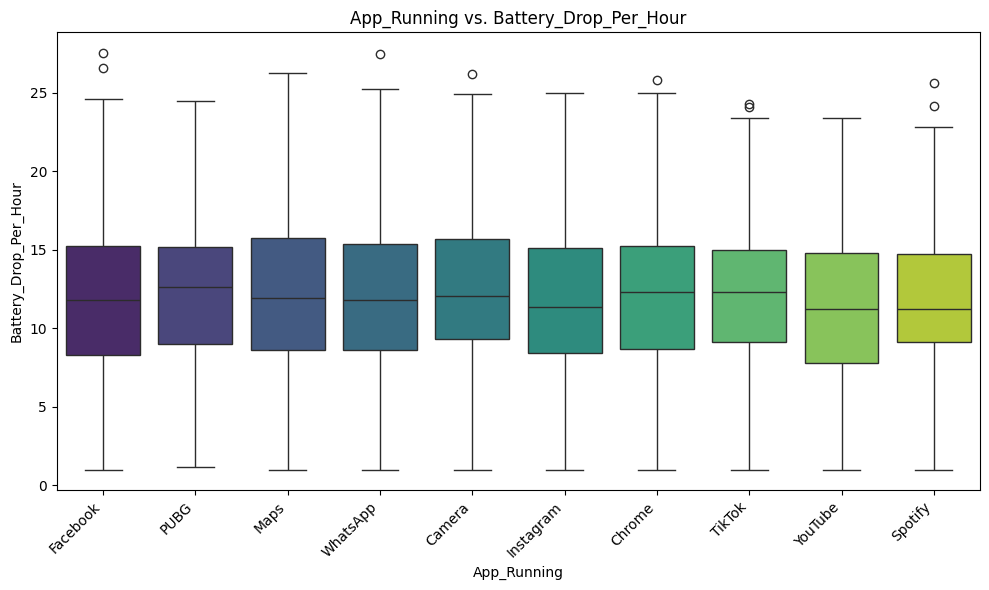

/tmp/ipykernel_1124/743069054.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=col, y='Battery_Drop_Per_Hour', palette='viridis')


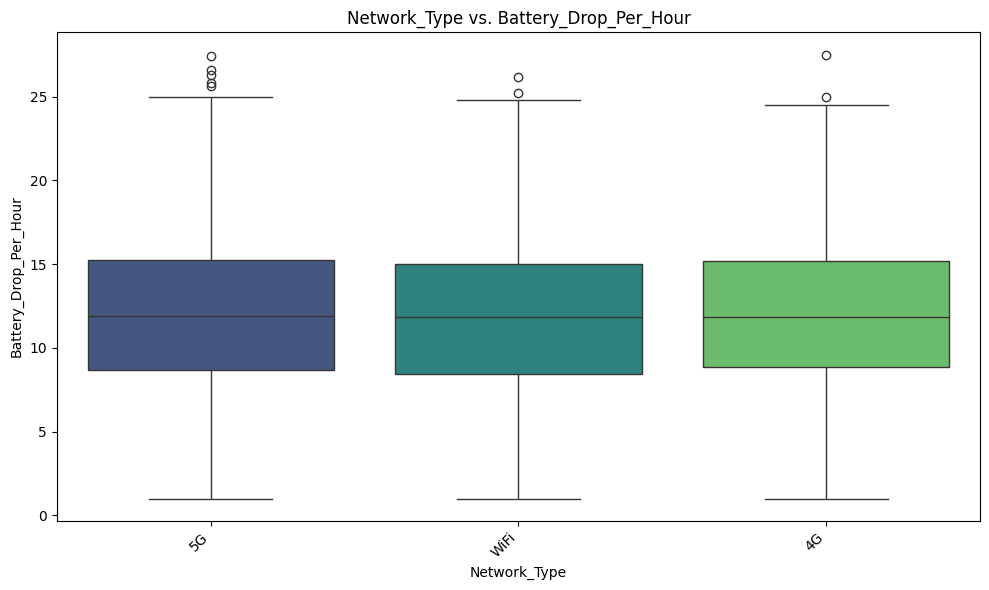

/tmp/ipykernel_1124/743069054.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=col, y='Battery_Drop_Per_Hour', palette='viridis')


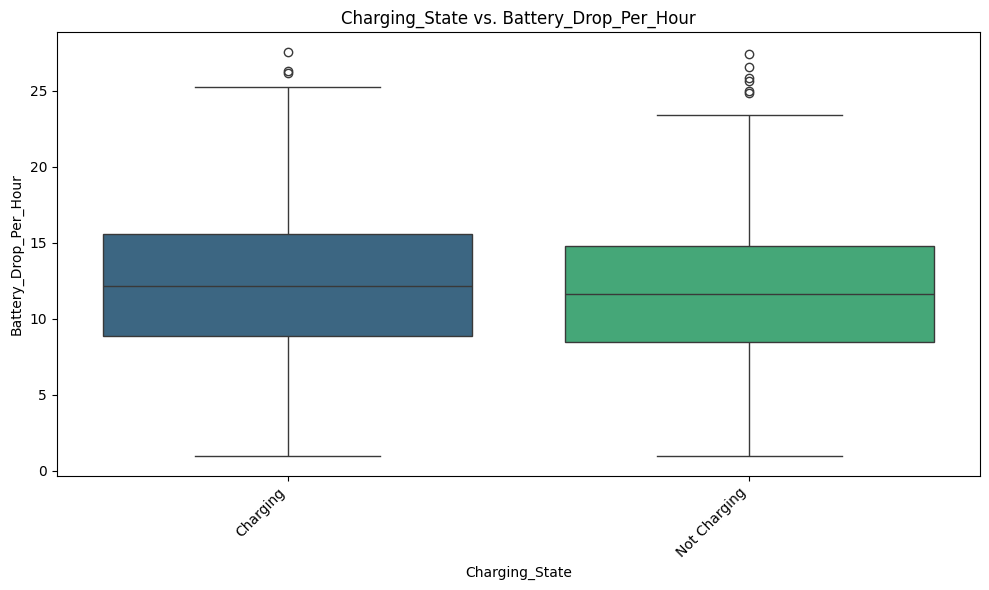

/tmp/ipykernel_1124/743069054.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=col, y='Battery_Drop_Per_Hour', palette='viridis')


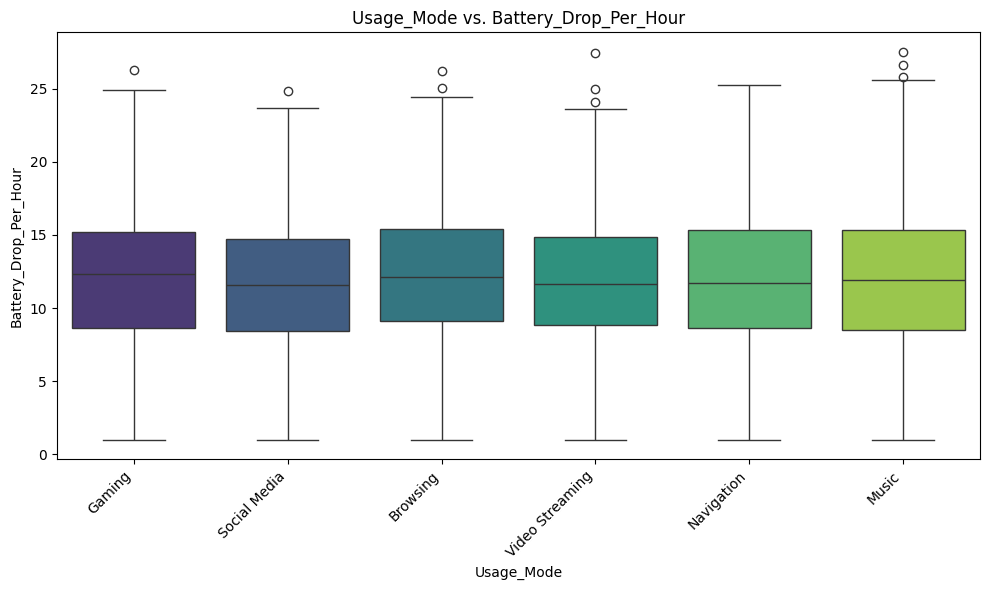

In [38]:
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=data, x=col, y='Battery_Drop_Per_Hour', palette='viridis')
    plt.title(f'{col} vs. Battery_Drop_Per_Hour')
    plt.xlabel(col)
    plt.ylabel('Battery_Drop_Per_Hour')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Pairplot

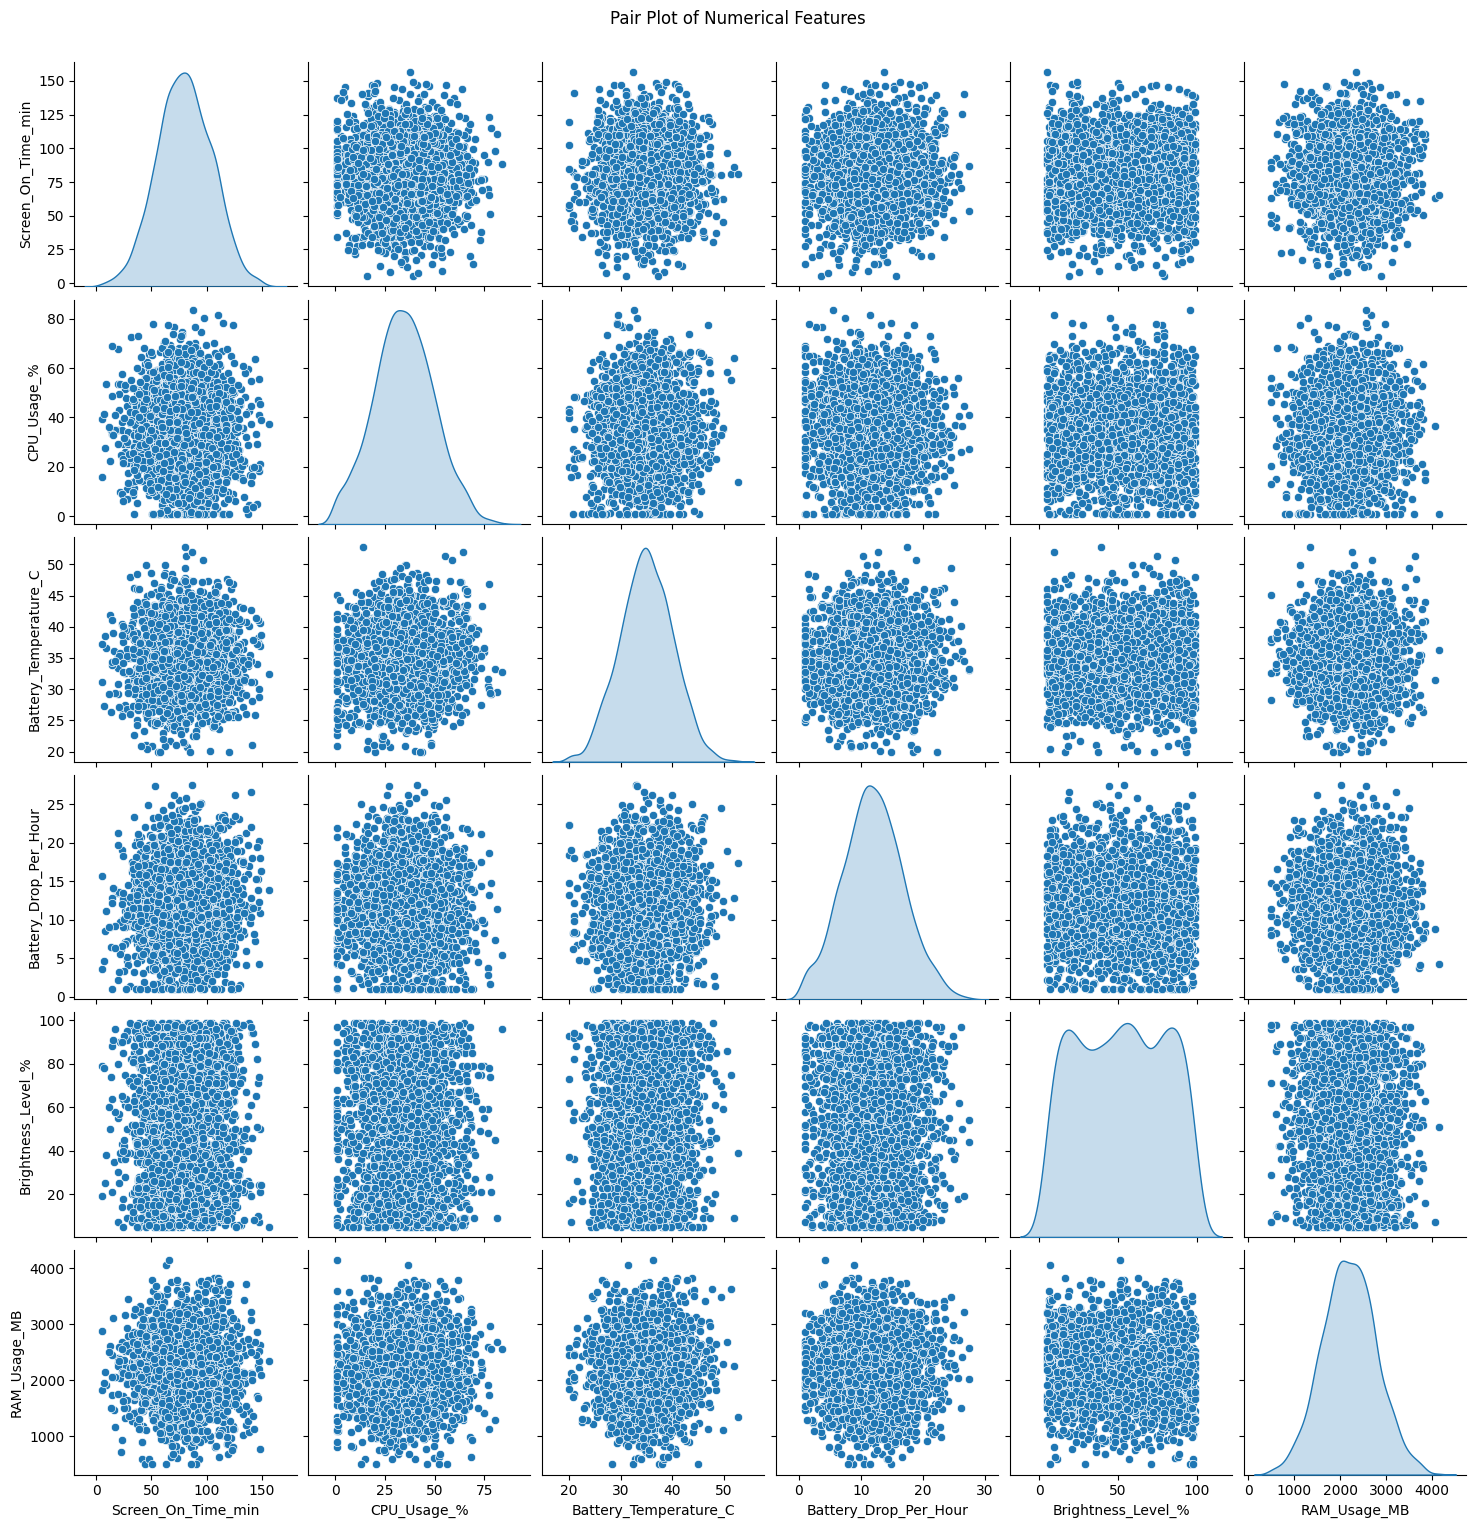

In [39]:
sns.pairplot(data[numerical_cols], diag_kind='kde')
plt.suptitle('Pair Plot of Numerical Features', y=1.02)
plt.show()

Key findings included-

- Multiple factors are associated with battery drain.
- Screen-on time is an important factor to investigate.
- CPU usage is relevant to battery-consumption analysis.
- Battery temperature provides useful contextual information.
- Brightness and RAM usage are additional factors.
- Battery drain varies across categorical conditions such as network, charging state, app, and usage mode.
- Correlation analysis helps identify relationships between numerical variables.
- The analysis is exploratory and does not establish causation.

# Conclusion



This exploratory data analysis examined smartphone battery consumption using 2,503 observations and 10 variables related to device usage, system resources, network conditions, charging state, and usage mode. A small number of missing values were identified in CPU usage and battery temperature, and the affected records were removed before further analysis.



The analysis used descriptive statistics, distributions, box plots, correlation analysis, scatter plots, categorical comparisons, and a pair plot to investigate factors associated with Battery_Drop_Per_Hour.



The numerical analysis helps identify relationships between battery drain and factors such as screen-on time, CPU usage, battery temperature, brightness level, and RAM usage. The categorical analysis further allows battery drain patterns to be compared across applications, network types, charging states, and usage modes.



Overall, the analysis demonstrates that smartphone battery consumption is related to multiple aspects of device usage rather than a single factor. The visualizations and correlation analysis provide useful insights into these relationships and help identify which variables deserve further investigation.



However, the analysis is exploratory and identifies associations rather than causal relationships. Further statistical testing or predictive modeling would be required to determine the strength and significance of individual factors.
